### Laufenburg GEFS Precipitation Forecast Exploration and Calibration

This notebook explores the GEFS precipitation forecasts for the Laufenburg region, and trains a CRPS-optimized Gamma Neural Network to calibrate the total precipitation forecast for the 120-144h forecast. Yay.


### Exploratory analysis of Laufenburg precipitation forecasts

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import StandardScaler


from hydro.common import PROCESSED_DIR
from hydro.models.nns import gamma_nn_model
from hydro.utils.skill import vectorized_crps, calculate_crps_from_gamma_params
import logging
logger = logging.getLogger(__name__)

data_path = os.path.join(PROCESSED_DIR, "dataset_gefs_era5_(47p5,8p0)_120-144_20230106_20250206.csv")

df = pd.read_csv(data_path, parse_dates=['forecast_date', 'valid_datetime_start', 'valid_datetime_end'])  # Adjust path
df = df.set_index('forecast_date')

df_train = pd.read_csv(os.path.join(PROCESSED_DIR, "dataset_gefs_era5_(47p5,8p0)_120-144_20230101_20231231_train.csv"))
df_test = pd.read_csv(os.path.join(PROCESSED_DIR, "dataset_gefs_era5_(47p5,8p0)_120-144_20240101_20250205_test.csv"))

member_cols = [col for col in df.columns if 'gefs_gep' in col]


ModuleNotFoundError: No module named 'pymc'

### Plot the GEFS vs ERA5 at Laufenburg, 120-144h (only plotting 2023)
Plot the mean, spread, and mark extremes obs that are > 90th percentile of obs.
Also calculate the % of spread breaches (i.e. where obs is outside the 10th-90th spread).
Only plot 2023 because it is easier to see. Add plots per year, as we get more data.

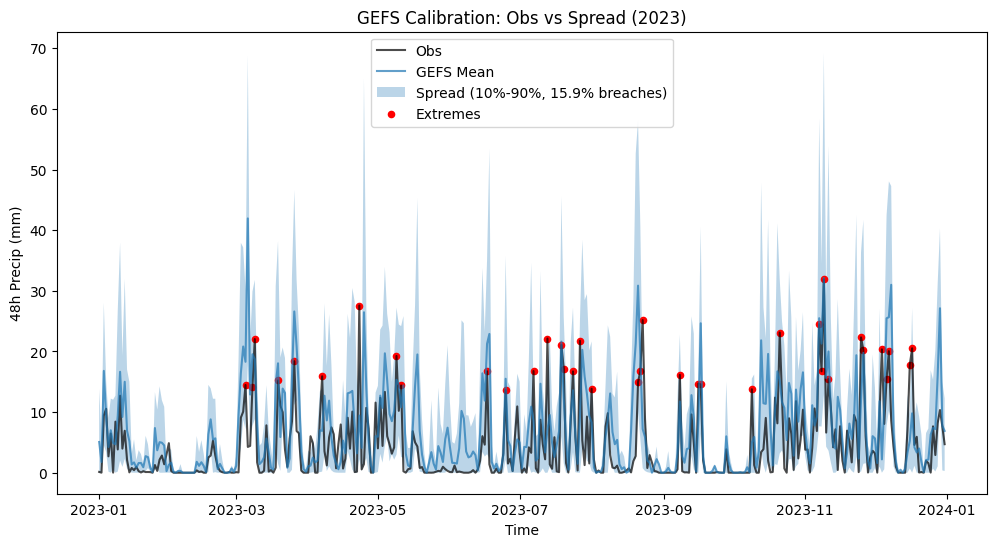

Breaches: 15.9% (mostly upper tail)


In [8]:
# Just plot the data we have in 2023
title_tag = "(2023)"
sub_df = df.loc[df.index.year == 2023,:].copy()


# Extremes (>90th obs)
extreme_thresh = sub_df['era5_tp'].quantile(0.9)
extremes = sub_df['era5_tp'] > extreme_thresh

# Spread breaches
sub_df['p10'] = sub_df[member_cols].quantile(0.1, axis=1)
sub_df['p90'] = sub_df[member_cols].quantile(0.9, axis=1)

breaches = (sub_df['era5_tp'] > sub_df['p90']) | (sub_df['era5_tp'] < sub_df['p10'])
breach_rate = breaches.mean() * 100

plt.figure(figsize=(12, 6))


plt.plot(sub_df.index, sub_df['era5_tp'], label='Obs', alpha=0.7, color='black')
plt.plot(sub_df.index, sub_df['gefs_geavg'], label='GEFS Mean', alpha=0.7)
plt.fill_between(sub_df.index, sub_df['p10'], sub_df['p90'], alpha=0.3, label=f'Spread (10%-90%, {breach_rate:.1f}% breaches)')
plt.scatter(sub_df[extremes].index, sub_df[extremes]['era5_tp'], color='red', s=20, label='Extremes')
plt.ylabel('48h Precip (mm)')
plt.xlabel('Time')
plt.legend()
title = 'GEFS Calibration: Obs vs Spread'
plt.title(title + f' {title_tag if title_tag else ""}')
plt.show()
print(f"Breaches: {breach_rate:.1f}% (mostly upper tail)")

### Investigate the skew of the obs vs the ensemble
Ensemble is "over-dispersed" (i.e. has more spread than the obs). Is this expected?

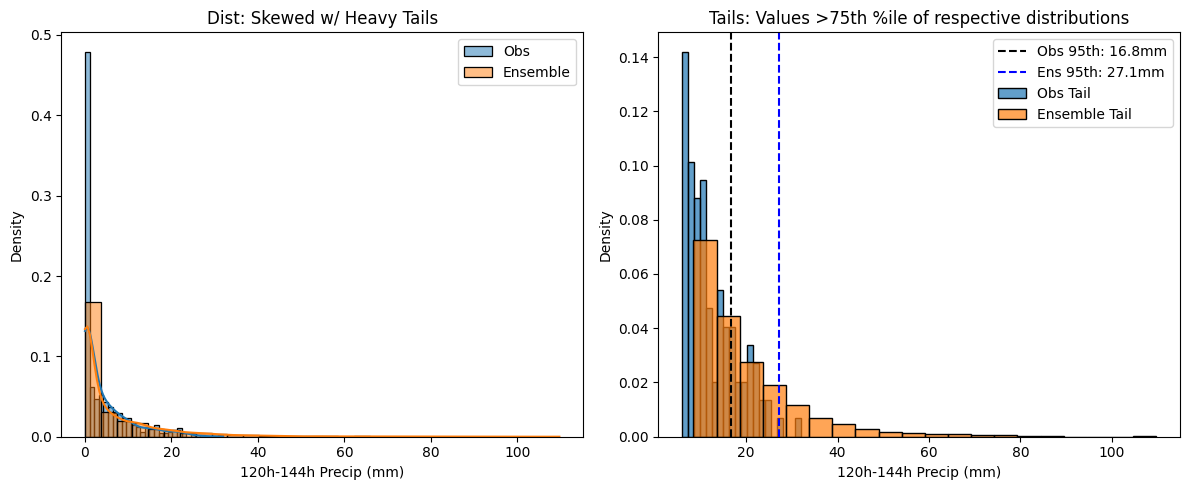

Obs 95th: 16.8mm vs Ensemble: 27.1mm (Bias: -61.5%)
Obs Skewness: 1.85 (positive = right-skewed)
Ensemble Skewness: 2.87


In [9]:

ensemble_flat = df[member_cols].values.flatten()

plt.figure(figsize=(12, 5))

# Left: Full Hist/KDE (skew/tails)
plt.subplot(1, 2, 1)
sns.histplot(df['era5_tp'], bins=30, kde=True, alpha=0.5, label='Obs', stat='density')
sns.histplot(ensemble_flat, bins=30, kde=True, alpha=0.5, label='Ensemble', stat='density')
plt.xlabel('120h-144h Precip (mm)')
plt.ylabel('Density')
plt.legend()
plt.title('Dist: Skewed w/ Heavy Tails')

# Right: Tail Focus (Zoom >75th %ile, with 95th lines)
tail_thresh = df['era5_tp'].quantile(0.75)
obs_tail = df['era5_tp'][df['era5_tp'] > tail_thresh]
ens_tail = ensemble_flat[ensemble_flat > np.quantile(ensemble_flat, 0.75)]
obs_q95 = df['era5_tp'].quantile(0.95)
ens_q95 = np.quantile(ensemble_flat, 0.95)

plt.subplot(1, 2, 2)
sns.histplot(obs_tail, bins=20, kde=False, alpha=0.7, label='Obs Tail', stat='density')
sns.histplot(ens_tail, bins=20, kde=False, alpha=0.7, label='Ensemble Tail', stat='density')
plt.axvline(obs_q95, color='black', linestyle='--', label=f'Obs 95th: {obs_q95:.1f}mm')
plt.axvline(ens_q95, color='blue', linestyle='--', label=f'Ens 95th: {ens_q95:.1f}mm')
plt.xlabel('120h-144h Precip (mm)')
plt.ylabel('Density')
plt.legend()
plt.title('Tails: Values >75th %ile of respective distributions')
# plt.xlim(tail_thresh, obs_tail.max() * 1.25)

plt.tight_layout()
plt.show()

# Quick Stats
print(f"Obs 95th: {obs_q95:.1f}mm vs Ensemble: {ens_q95:.1f}mm (Bias: {((obs_q95 - ens_q95)/obs_q95*100):+.1f}%)")
print(f"Obs Skewness: {stats.skew(df['era5_tp']):.2f} (positive = right-skewed)")
print(f"Ensemble Skewness: {stats.skew(ensemble_flat):.2f}")

### CRPS of GEFS at Laufenburg, 120-144h

Below we look at the empirical CRPS of the GEFS ensemble tp forecasts at Laufenburg, Germany. We compare the CRPS of the full dataset, the training set, the test set, and the tail subset of the training set. These provide baselines to compare against the CRPS of the calibrated GEFS ensemble.

Training set is all of 2023. Test set is part of 2024 and 2025
CRPS is stable between training and test. Probably not surprisingly, CRPS is worse for extremes

In [10]:
# all data
members_all = df[member_cols].values
obs_all = df["era5_tp"].values
crps_all = vectorized_crps(members_all, obs_all)
df["crps"] = crps_all

# training data
members_train = df_train[member_cols].values
obs_train = df_train["era5_tp"].values
crps_train = vectorized_crps(members_train, obs_train)
df_train["crps"] = crps_train

# test data
members_test = df_test[member_cols].values
obs_test = df_test["era5_tp"].values
crps_test = vectorized_crps(members_test, obs_test)
df_test["crps"] = crps_test

# Tail subset (>90th obs on train for thresh)
extreme_thresh = df_train["era5_tp"].quantile(0.9)
train_ext = df_train[df_train["era5_tp"] > extreme_thresh]
test_ext = df_test[df_test["era5_tp"] > extreme_thresh]

# Table
metrics = pd.DataFrame(
    {
        "Dataset": [
            "All Data",
            "Train All",
            "Train Extremes",
            "Test All",
            "Test Extremes",
        ],
        "CRPS (mm)": [
            df["crps"].mean(),
            df_train["crps"].mean(),
            train_ext["crps"].mean(),
            df_test["crps"].mean(),
            test_ext["crps"].mean() if len(test_ext) > 0 else np.nan,
        ],
    }
)
print(metrics.round(2))

# # Save updated CSVs
# df_train.to_csv("rhine_train_with_crps.csv", index=False)
# df_test.to_csv("rhine_test_with_crps.csv", index=False)

          Dataset  CRPS (mm)
0        All Data       2.25
1       Train All       2.31
2  Train Extremes       6.08
3        Test All       2.01
4   Test Extremes       7.25


### Build a model

In [14]:
# Prepare Training Data
pred_cols = ['gefs_geavg', 'gefs_gespr', 'gefs_ensemble_min', 'gefs_ensemble_max',
'gefs_ensemble_q10', 'gefs_ensemble_q90', 'gefs_ensemble_skew', 'gefs_ensemble_kurtosis',
'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

X_train = df_train[pred_cols].values
X_test = df_test[pred_cols].values
y_train = df_train['era5_tp'].values
y_test = df_test['era5_tp'].values

# Scale features (fit on train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define a NN with an input layer, two hidden layers, and an output layer.
# The output layer has two neurons, using softplus to ensure the output is positive.
model = gamma_nn_model(X_train, (32, 32, 32))


# Train
dummy_y_train = np.column_stack([np.ones(len(y_train)), y_train])
history = model.fit(X_train, dummy_y_train,
                    epochs=500, batch_size=64, validation_split=0.2, verbose=1)

# Predict on test: Sample Gamma, compute CRPS
gamma_test = model.predict(X_test)  # (N_test, 2)
crps_model = calculate_crps_from_gamma_params(gamma_test, y_test)

mean_crps_model = np.mean(crps_model)
print(f"Model CRPS: {mean_crps_model:.2f}mm (vs. baseline {df_test['crps'].mean():.2f}mm; Improvement: {((df_test['crps'].mean() - mean_crps_model)/df_test['crps'].mean()*100):.1f}%)")

# Tail CRPS
test_ext_idx = df_test['era5_tp'] > df_test['era5_tp'].quantile(0.9)
test_ext = df_test[test_ext_idx]
ext_crp_mean = crps_model[test_ext_idx].mean()
print(f"Model Extreme CRPS: {ext_crp_mean:.2f}mm (vs. baseline {test_ext['crps'].mean():.2f}mm)")

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 2.9455 - val_loss: 5.8545
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6938 - val_loss: 5.4299
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5687 - val_loss: 4.9645
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.4570 - val_loss: 4.9347
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3419 - val_loss: 4.9193
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2795 - val_loss: 4.7852
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2020 - val_loss: 4.7703
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1454 - val_loss: 4.6353
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0628 - val_loss: 4.6231
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0215 - val_loss: 4.5646
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9462 - val_loss: 4.5129
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8972 - val_los